In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import time
import sys
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from torch.utils.data import Subset
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import pandas as pd

In [8]:
# VGG-16 model, first model attempted 

class vgg16_conv_block(nn.Module):
    def __init__(self, input_channels, out_channels, rate=0.3, drop=True):
        super().__init__()
        self.conv = nn.Conv2d(input_channels, out_channels, 3, 1, 1)  #This line creates a 2D convolutional layer using PyTorch's nn.Conv2d module.
        self.bn = nn.BatchNorm2d(out_channels) # normalize the activations of the convolutional layer in the neural network.
        self.relu = nn.ReLU(inplace=True) #introduces non-linearity (-ve --> zeros)
        self.dropout = nn.Dropout(rate)
        self.drop = drop

        def forward(self, x):  #This method defines the forward pass of the convolutional block.
            x = self.relu(self.bn(self.conv(x)))
            if self.drop:
              x = self.dropout(x)
            return x
    

# It specifies how many (convolutional blocks) to build and what features each network should have
# creating a sequence of convolutional blocks followed by a max-pooling layer
# 0.3 corresponds to the dropout rate for the convolutional blocks within each layer, and the second value 0.4 represents the dropout rate for the fully connected layers in the VGG16 model.

def vgg16_layer(input_channels, out_channels, num, dropout=[0.3, 0.4]):
    layers = []
    for i in range(num):  #creating convolutional blocks using the vgg16_conv_block function.
        layers.append(vgg16_conv_block(input_channels, out_channels, dropout[0]))
        input_channels = out_channels  #ensuring that subsequent blocks receive the correct number of input channels.
    layers.append(nn.MaxPool2d(2, 2))  # 2 by 2 max pooling layer
    return nn.Sequential(*layers)

# This is like the blueprint for the entire neural network.
# It specifies how to arrange the (layers) and what features each layers should have.

class ModifiedVGG16(nn.Module):
    def __init__(self):
        super(ModifiedVGG16, self).__init__()
        self.features = nn.Sequential(
            vgg16_layer(1, 16, 2),  # Adjust input channels to 1
            vgg16_layer(16, 32, 2),
            vgg16_layer(32, 64, 2),
            vgg16_layer(64, 128, 2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(128, 10, bias=True)
        )

    # defines how data flows through the network during the forward pass.
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.31MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 5.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.05MB/s]


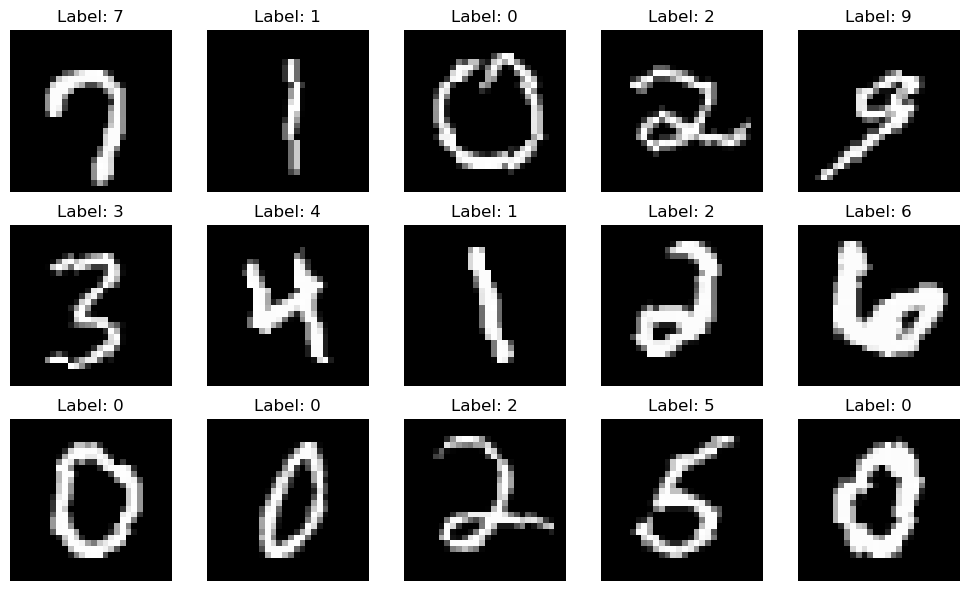

In [9]:
# Define transforms for the dataset

# ***** Add more data augmenation
#   random rotation, horizontal flip, random affine transformation,
#   random vertical flip, random perspective transformation, random brightness adjustment,
#   and random contrast adjustment   **********

transform_plus = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the full MNIST dataset
trainset_full = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform_plus)
testset_full = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform_plus)

# Define the number of samples you want to use for training and testing
num_train_samples = 5000  # Example: Use 5000 samples for training
num_test_samples = 1000   # Example: Use 1000 samples for testing

# Create subsets of the full dataset
train_indices = torch.randperm(len(trainset_full))[:num_train_samples]
test_indices = torch.randperm(len(testset_full))[:num_test_samples]

trainset= Subset(trainset_full, train_indices)
testset= Subset(testset_full, test_indices)

# Load a batch of images and labels from the trainset
batch_size = 15
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

# Define a function to display a grid of images
def show_images(images, labels, nrows=3, ncols=5, figsize=(10, 6)):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Label: {labels[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Iterate over the trainloader to get a batch of data
for images, labels in trainloader:
    # Display the images
    show_images(images, labels)
    break  # Break after displaying the first batch